# Определение возраста покупателей

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

- анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- контролировать добросовестность кассиров при продаже алкоголя.

Необходимо построить модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием возраста.

Перед нами задача регрессии. На выходе будет 1 слой с ReLU функцией активации, чтобы, например привести к 0 все отрицательные числа.

Данные взяты с сайта [ChaLearn Looking at People](http://chalearnlap.cvc.uab.es/dataset/26/description/).

## 1. <a id='toc1_'></a>Подготовка   [&#8593;](#toc0_)

### 1.1. <a id='toc1_1_'></a>Библиотеки   [&#8593;](#toc0_)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from termcolor import colored
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,
                                     GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam

### <a id='toc1_2_'></a>Конфигурация   [&#8593;](#toc0_)

In [2]:
IMAGE_SIZE = (128, 128)
RANDOM_STATE = 27
BATCH_SIZE = 8
EPOCHS = 10

##  <a id='toc2_'></a>Данные   [&#8593;](#toc0_)

###  <a id='toc2_1_'></a>Загрузка   [&#8593;](#toc0_)

In [3]:
y_train = pd.read_csv('/datasets/faces/labels.csv', usecols=['file_name', 'real_age']).drop_duplicates()
y_train.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [14]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 177.9+ KB


In [5]:
y_train.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


###  <a id='toc2_2_'></a>Распределение по возрастам   [&#8593;](#toc0_)

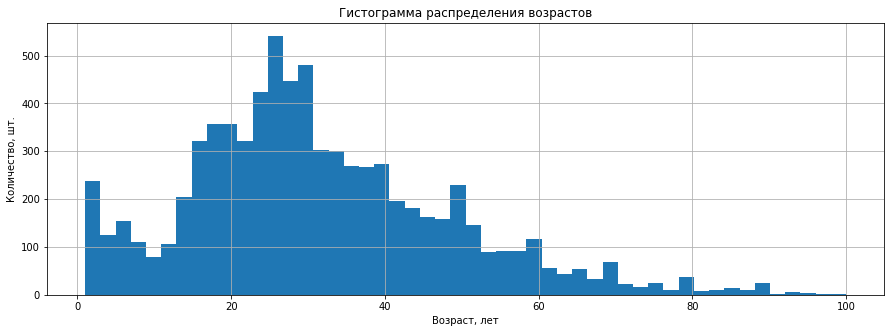

In [6]:
plt.figure(figsize=(15, 5))
y_train['real_age'].hist(bins=50)
plt.title('Гистограмма распределения возрастов')
plt.xlabel('Возраст, лет')
plt.ylabel('Количество, шт.')
plt.show()

###  <a id='toc2_3_'></a>Визуальный осмотр   [&#8593;](#toc0_)

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255)
train_gen_flow = train_datagen.flow_from_dataframe(
    dataframe=y_train,
    directory='/datasets/faces/final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode='raw',
    seed=RANDOM_STATE
)

Found 7591 validated image filenames.


In [8]:
images, labels = next(train_gen_flow)
images = images[:10]
labels = labels[:10]

In [9]:
rows, cols = 5, 2

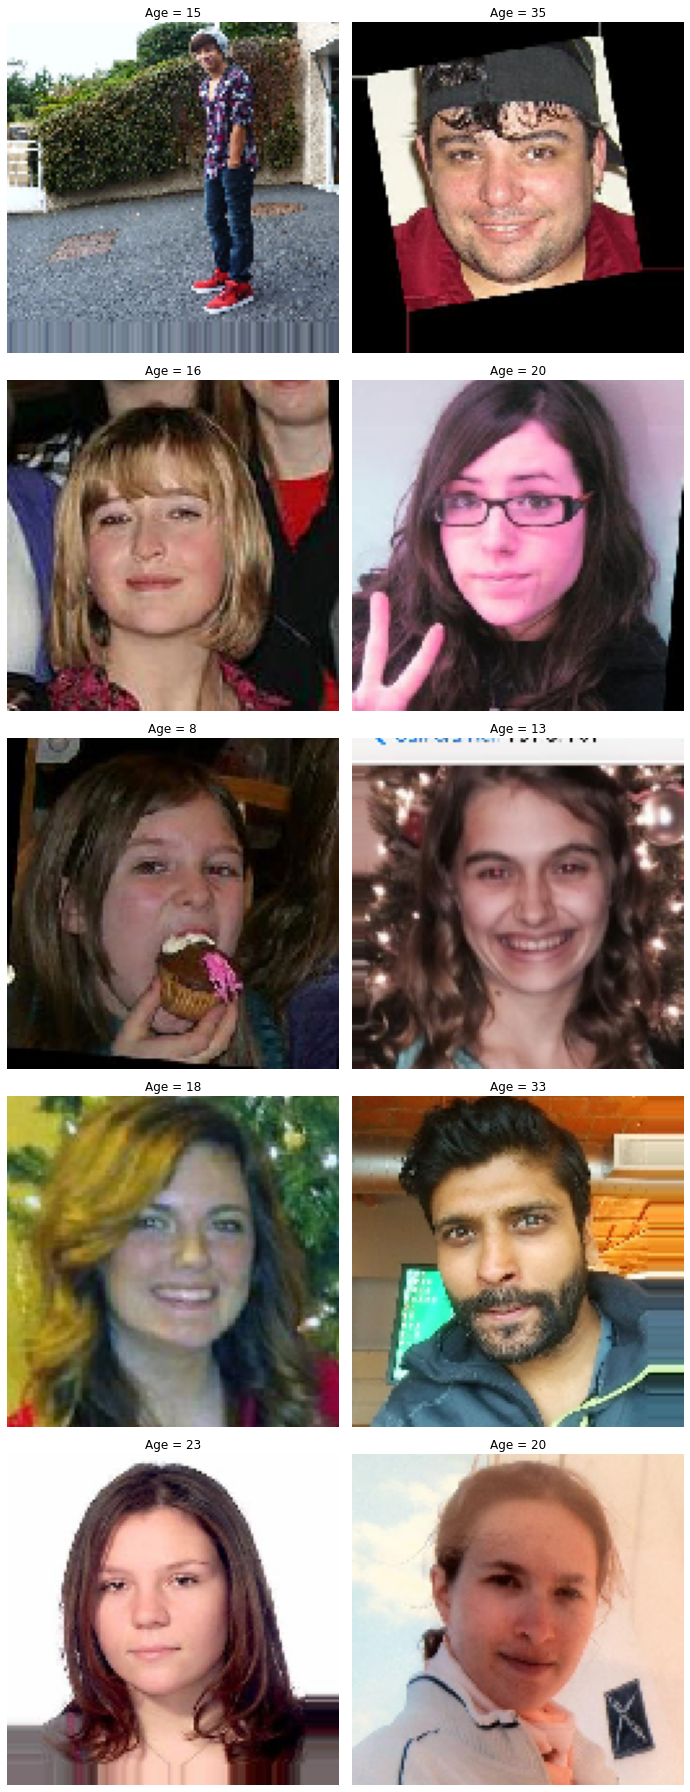

In [10]:
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))

for i, (img, label) in enumerate(zip(images, labels)):
    row = i // cols
    col = i % cols
    ax = axes[row, col]
    ax.imshow(img)
    ax.set_title(f'Age = {label}')
    ax.axis('off')

plt.tight_layout()
plt.show()

###  <a id='toc2_4_'></a>Выводы по данным   [&#8593;](#toc0_)

На предоставленных фотографиях изображены люди разного пола и возраста. Можно выделить следующие наблюдения:

* Возрастной диапазон: представлен широкий спектр — от детей (примерно 8 лет) до взрослых (до 35 лет).

* Гендерное распределение: сбалансировано — присутствуют как мужчины, так и женщины.

* Смещение по возрасту: наблюдается смещение влево — значительная часть изображённых моложе 25 лет.

* Формат изображений: часть фотографий — кадрированы или повернуты, что может повлиять на точность автоматического определения возраста.


Таким образом, изображения разнообразны по возрасту и полу, но имеют тенденцию к заниженным возрастам, а также отличаются по качеству и ориентации.

##  <a id='toc3_'></a>Предсказание   [&#8593;](#toc0_)

###  <a id='toc3_2_'></a>Модель   [&#8593;](#toc0_)

In [ ]:
path = '/datasets/faces/'

data = pd.read_csv(path + 'labels.csv')

datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

train_datagen_flow = datagen.flow_from_dataframe(
    dataframe=data,
    directory=path + 'final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(128, 128),     
    batch_size=8,
    class_mode='raw',
    subset='training',
    seed=12345
)

valid_datagen_flow = datagen.flow_from_dataframe(
    dataframe=data,
    directory=path + 'final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(128, 128),
    batch_size=8,
    class_mode='raw',
    subset='validation',
    seed=12345
)

backbone = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

model = Sequential([
    backbone,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(1, activation='relu')  
])

optimizer = Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

model.summary()

EPOCHS = 5

history = model.fit(
    train_datagen_flow,
    steps_per_epoch=len(train_datagen_flow),
    validation_data=valid_datagen_flow,
    validation_steps=len(valid_datagen_flow),
    epochs=EPOCHS,
    verbose=1
)

Found 6073 validated image filenames.
Found 1518 validated image filenames.


2025-05-29 21:52:35.262805: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


94781440/94765736 [==============================] - 3s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 4, 4, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 24,112,513
Trainable params: 24,059,393
Non-trainable params: 53,120
_________________________________________________________________
Epoch 1/5
760/760 [=====================

In [ ]:
model.save('age_model.h5')

##  <a id='toc4_'></a>Результаты  [&#8593;](#toc0_)

### <a id='toc4_1_'></a>Проверка на тесте  [&#8593;](#toc0_)

In [ ]:
test_loss, test_mae = model.evaluate(valid_datagen_flow, steps=len(valid_datagen_flow))
print(f"Test Loss: {test_loss:.2f}, Test MAE: {test_mae:.2f}")

## <a id='toc5_'></a>Итоговый вывод   [&#8593;](#toc0_)

В рамках данного проекта мы работали с датасетом, содержащим изображения людей. Целевой признак - их возраст. В датасете представлены изображения людей обоих полов и самых разных возрастов.

В качестве модели использовался бэкбон *ResNet50* с весами от *imagenet*, один скрытый Dense слой с `256` нейронами и 1 выходной слой с ожидаемо `1` нейроном. Использовалась ReLU функция активации в обоих слоях. В результате, получена метрика `MAE ~ 7`, что лучше, чем требовалось.

Однако использовать такую модель в реальной жизни не стоит. Ошибка в `7` лет довольна критична для целей заказчика. Ведь у людей 7 и 14 лет совершенно разные "интересные им" товары. Модель могла бы быть относительно полезной для людей старшей возрастной категории - люди в 50 и 57 покупают примерно одно.